# 用 TensorFlow 手写线性分类器：逐行拆解版

> **这份笔记做什么？**
>
> 用最简单的例子（两团二维点）演示神经网络训练的完整流程：
> 生成数据 → 定义模型 → 定义损失 → 梯度下降更新参数 → 看结果。
>
> 和 MNIST 手写数字识别的区别：
> - MNIST：784个像素 → 512个神经元 → 10个类别，40万个参数
> - 这里：2个坐标 → 1个输出，只有3个参数（w₁, w₂, b）
>
> 但训练的核心逻辑完全一样：前向传播 → 算loss → 反向传播 → 更新参数。
> 先用3个参数搞明白这条主线，再去看40万个参数的版本就不慌了。

---
## Cell 1：导入库

三个库各管一件事：
- `numpy`：生成模拟数据（造两团点）
- `tensorflow`：搭模型、算梯度、更新参数（训练的核心）
- `matplotlib`：画图（看数据长什么样、分界线在哪）

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print(f"NumPy 版本：{np.__version__}")
print(f"TensorFlow 版本：{tf.__version__}")

NumPy 版本：2.4.2
TensorFlow 版本：2.21.0


---
## Cell 2：固定随机种子

随机种子 = 让"随机"变得可重复。
设了种子之后，每次运行生成的随机数都一样，方便调试和对比结果。
不设的话每次跑出来的数据和训练结果都不一样。

In [ ]:
np.random.seed(123)       # numpy 的随机种子
tf.random.set_seed(123)   # tensorflow 的随机种子

---
## Cell 3：生成两类二维点数据

我们要造一个最简单的分类问题：平面上有两团点，让模型学一条直线把它们分开。

### 每个点长什么样？
每个点就是一个 (x₁, x₂) 坐标，比如 (1.2, 2.8)。

### 两团点怎么造？
用**二维高斯分布**（正态分布的二维版本）来生成：
> 这里解释一下：
> 1. 一维正态分布 → 点撒在一条数轴上 → 每个点只有一个数 x。
> 2. 二维正态分布 → 点撒在一个平面上 → 每个点有两个数 (x₁, x₂)，就是你说的 x 轴和 y 轴坐标。

#### 均值 μ：点团的中心在哪

往墙上扔飞镖，你瞄准的那个点就是均值。

μ=0，飞镖扎在0附近。μ=3，飞镖扎在3附近。均值只管"中心在哪"，不管"散多开"。

```
μ=0：大部分点挤在0附近          μ=3：大部分点挤在3附近
     ████                                    ████
    ██████                                  ██████
  ██████████                              ██████████
──────────────→                 ──────────────────────→
-2  -1  0  1  2                 0   1   2   3   4   5
     ↑ 中心在这                          ↑ 中心在这
```

#### 方差 σ²：点散得多开

均值是你瞄哪，方差是你手抖不抖。

方差小 → 手稳，飞镖全扎在一小块区域。方差大 → 手抖，飞镖满墙乱飞。

```
σ²=0.2（手稳，点很集中）：       σ²=5（手抖，点很分散）：
        ██                        ·
       ████                      · ·  ·
       ████                    ·  ···  ··
        ██                    ·  ·····  · ·
──────────────→              ·  ·······  ·  ·
-2  -1  0  1  2              ···████████···  ·
                           ──────────────────────→
                           -6  -4  -2  0  2  4  6
```

#### 标准差 σ：方差开个根号

方差和标准差说的是同一件事。一块地面积9平方米（σ²=9），边长3米（σ=3）。标准差就是方差开根号，数字更直观。

记一个规律就够了：**68%的点落在均值左右各一个标准差的范围内**。

```
μ=0, σ=1（标准差=1）：
68% 的点落在 [0-1, 0+1] = [-1, 1] 之间
95% 的点落在 [0-2, 0+2] = [-2, 2] 之间

μ=0, σ=3（标准差=3）：
68% 的点落在 [0-3, 0+3] = [-3, 3] 之间
95% 的点落在 [0-6, 0+6] = [-6, 6] 之间
```

σ 越大，这个范围越宽，点越散。

In [2]:
num_samples_per_class = 1000   # 每类生成1000个点，两类共2000个

# ── 第一类：中心在 (0, 3) 附近 ──
# 生成的点大概散落在 (0, 3) 周围
negative_samples = np.random.multivariate_normal(
    mean=[0, 3],                      # 中心坐标
    cov=[[1, 0.5], [0.5, 1]],         # 协方差矩阵（控制形状）
    size=num_samples_per_class        # 生成1000个点
)

# ── 第二类：中心在 (3, 0) 附近 ──
positive_samples = np.random.multivariate_normal(
    mean=[3, 0],
    cov=[[1, 0.5], [0.5, 1]],
    size=num_samples_per_class
)

print(f"第一类点的形状：{negative_samples.shape}")   # (1000, 2) → 1000个点，每个点2个坐标
print(f"第二类点的形状：{positive_samples.shape}")   # (1000, 2)
print(f"\n第一类前5个点（大概在(0,3)附近）：")
print(negative_samples[:5])
print(f"\n第二类前5个点（大概在(3,0)附近）：")
print(positive_samples[:5])

第一类点的形状：(1000, 2)
第二类点的形状：(1000, 2)

第一类前5个点（大概在(0,3)附近）：
[[ 0.51481243  3.15376439]
 [ 1.15484213  3.59904311]
 [-0.02896671  3.02662298]
 [ 0.95368825  2.09672968]
 [ 0.89979124  3.20100354]]

第二类前5个点（大概在(3,0)附近）：
[[ 2.51355979 -0.67152768]
 [ 3.67668355  1.91399364]
 [ 3.31575732  1.11894123]
 [ 3.00320435  2.43995964]
 [ 1.33843092  0.65943171]]


---
## Cell 4：拼接输入数据

把两类点上下拼起来，变成一个大矩阵。

### `np.vstack` 是什么？
`vstack` = vertical stack = 垂直堆叠 = 把两个矩阵上下拼起来。

```
第一类 (1000, 2)     →  拼起来  →  inputs (2000, 2)
第二类 (1000, 2)     ↗
```

前1000行是第一类的点，后1000行是第二类的点。

### `astype("float32")` 是什么？
把数据类型转成32位浮点数。TensorFlow 做矩阵乘法需要浮点数，
原始 numpy 默认是 float64，转成 float32 更快、更省内存。

In [3]:
# np.vstack：把两个 (1000, 2) 上下拼成 (2000, 2)
# astype("float32")：转成TF需要的浮点类型
inputs = np.vstack((negative_samples, positive_samples)).astype("float32")

print(f"inputs 形状：{inputs.shape}")          # (2000, 2)
print(f"含义：{inputs.shape[0]} 个样本，每个样本 {inputs.shape[1]} 个特征（x₁坐标和x₂坐标）")
print(f"\n前3个点（来自第一类）：{inputs[:3]}")
print(f"第1001个点（来自第二类）：{inputs[1000]}")

inputs 形状：(2000, 2)
含义：2000 个样本，每个样本 2 个特征（x₁坐标和x₂坐标）

前3个点（来自第一类）：[[ 0.5148124   3.1537645 ]
 [ 1.1548421   3.5990431 ]
 [-0.02896671  3.026623  ]]
第1001个点（来自第二类）：[ 2.5135598 -0.6715277]


---
## Cell 5：生成标签

标签就是"正确答案"：
- 前1000个点 → 标签 = 0（第一类）
- 后1000个点 → 标签 = 1（第二类）

### 为什么用 `np.zeros` 和 `np.ones`？
- `np.zeros((1000, 1))` → 生成1000个0，形状 (1000, 1)
- `np.ones((1000, 1))` → 生成1000个1，形状 (1000, 1)
- `np.vstack` 拼起来 → (2000, 1)

### 为什么标签形状是 (2000, 1) 而不是 (2000,)？
因为模型输出 `predictions` 的形状是 (2000, 1)（矩阵乘法的结果），
标签也要是 (2000, 1) 才能和 predictions 做减法算 loss。形状必须对齐。

In [4]:
# 前1000个标签=0，后1000个标签=1
targets = np.vstack((
    np.zeros((num_samples_per_class, 1), dtype="float32"),   # 1000个0
    np.ones((num_samples_per_class, 1), dtype="float32")     # 1000个1
))

print(f"targets 形状：{targets.shape}")       # (2000, 1)
print(f"前3个标签：{targets[:3].flatten()}")   # [0, 0, 0]  → 第一类
print(f"第1001个标签：{targets[1000].flatten()}")  # [1]  → 第二类
print(f"\n标签统计：0有{int((targets==0).sum())}个，1有{int((targets==1).sum())}个")

targets 形状：(2000, 1)
前3个标签：[0. 0. 0.]
第1001个标签：[1.]

标签统计：0有1000个，1有1000个


---
## Cell 6：可视化原始数据

画散点图看看两团点长什么样。

### 代码怎么读？
- `inputs[:, 0]`：所有点的第1个坐标（x₁），作为横轴
- `inputs[:, 1]`：所有点的第2个坐标（x₂），作为纵轴
- `c=targets[:, 0]`：按标签上色，0是一个颜色，1是另一个颜色
- `s=10`：点的大小

你应该会看到两团点，大致可以用一条直线分开。

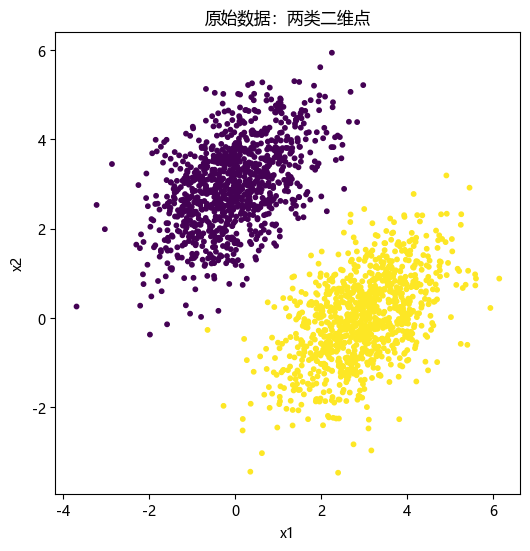

In [7]:
plt.figure(figsize=(6, 6))
plt.scatter(
    inputs[:, 0],
    inputs[:, 1],
    c=targets[:, 0],
    s=10
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("原始数据：两类二维点")
plt.show()

---
## Cell 7：创建模型参数（W 和 b）

### 这个模型有多简单？

输入是2个数（x₁, x₂坐标），输出是1个数（预测值）。
整个模型就是一个公式：

$$\hat{y} = w_1 \cdot x_1 + w_2 \cdot x_2 + b$$

只有3个参数：w₁、w₂、b。

写成矩阵形式：$\hat{y} = X \cdot W + b$

其中：
- X 形状 (2000, 2)：2000个样本，每个2个特征
- W 形状 (2, 1)：2个权重（w₁和w₂）
- b 形状 (1,)：1个偏置
- 输出形状 (2000, 1)：2000个预测值

### `tf.Variable` 是什么？
告诉 TensorFlow "这个值是需要学习的参数"。
普通张量是固定的，Variable 是可以被修改的。
后面 GradientTape 只会对 Variable 类型的东西算梯度。

### 为什么 W 随机初始化、b 初始化为零？
和 MNIST 那个例子一样的道理：
- W 随机 → 让模型从不同的起点开始搜索
- b 为零 → 偏置不影响对称性，零起步没问题

In [8]:
input_dim = 2     # 输入特征数：x₁ 和 x₂ 两个坐标
output_dim = 1    # 输出数：1个预测值（接近0=第一类，接近1=第二类）

# W — 权重矩阵
#   形状：(2, 1)
#   含义：w₁ 和 w₂，分别是 x₁ 和 x₂ 的权重
#   初始化：0~1之间的随机数
W = tf.Variable(
    initial_value=tf.random.uniform(shape=(input_dim, output_dim))
)

# b — 偏置
#   形状：(1,)
#   含义：整条直线上下平移的量
#   初始化：0
b = tf.Variable(
    initial_value=tf.zeros(shape=(output_dim,))
)

print(f"W 形状：{W.shape}")        # (2, 1)
print(f"b 形状：{b.shape}")        # (1,)
print(f"\n初始 W（随机值）：")
print(f"  w₁ = {W.numpy()[0, 0]:.4f}  （x₁ 的权重）")
print(f"  w₂ = {W.numpy()[1, 0]:.4f}  （x₂ 的权重）")
print(f"初始 b = {b.numpy()[0]:.4f}")
print(f"\n总参数量：{W.numpy().size + b.numpy().size} 个")  # 3个
print(f"\n对比 MNIST：407,050 个参数。这里只有3个，最小的神经网络。")

W 形状：(2, 1)
b 形状：(1,)

初始 W（随机值）：
  w₁ = 0.8467  （x₁ 的权重）
  w₂ = 0.1508  （x₂ 的权重）
初始 b = 0.0000

总参数量：3 个

对比 MNIST：407,050 个参数。这里只有3个，最小的神经网络。


---
## Cell 8：定义前向传播

前向传播 = 从输入算出预测值。

对单个样本 $[x_1, x_2]$：
$$\hat{y} = w_1 \cdot x_1 + w_2 \cdot x_2 + b$$

对一批2000个样本（矩阵写法）：
$$\text{predictions} = X \cdot W + b$$

维度变化：$(2000, 2) \times (2, 1) = (2000, 1)$

### `tf.matmul` 是什么？
矩阵乘法，和 MNIST 例子里的 `tf.matmul(x, W1)` 一模一样。
那里是 (128, 784) × (784, 512)，这里是 (2000, 2) × (2, 1)。
维度不同，但操作完全一样：每一行和 W 做点积。

In [9]:
def model(inputs):
    """
    前向传播：输入坐标，输出预测值。

    参数
    ----
    inputs : numpy.ndarray 或 tf.Tensor, 形状 (batch_size, 2)
        一批样本的坐标，每行是一个点的 [x₁, x₂]。

    返回
    ----
    predictions : tf.Tensor, 形状 (batch_size, 1)
        每个样本的预测值。
        接近0 → 模型认为是第一类。
        接近1 → 模型认为是第二类。

    计算过程
    -------
    predictions = inputs × W + b
    (2000, 2) × (2, 1) + (1,) = (2000, 1)

    展开来看，对第 i 个样本：
    predictions[i] = inputs[i, 0] × W[0, 0] + inputs[i, 1] × W[1, 0] + b[0]
                   = x₁ × w₁ + x₂ × w₂ + b
    """
    # tf.matmul：矩阵乘法，等价于 MNIST 里的 dot(x, W)
    # + b：广播加法，b 的形状 (1,) 会自动扩展到 (2000, 1)
    return tf.matmul(inputs, W) + b


# ── 试跑一下，看看没训练之前预测出来是什么样 ──
raw_predictions = model(inputs)
print(f"预测值形状：{raw_predictions.shape}")        # (2000, 1)
print(f"前5个预测值：{raw_predictions[:5].numpy().flatten()}")
print(f"\n此时 W 和 b 还是随机值/零，预测结果没有任何意义。")

预测值形状：(2000, 1)
前5个预测值：[0.91134727 1.5204083  0.43174475 1.1236068  1.2444428 ]

此时 W 和 b 还是随机值/零，预测结果没有任何意义。


---
## Cell 9：定义损失函数（均方误差 MSE）

### 损失函数是什么？
损失 = 预测值和正确答案差了多远的度量。
loss 越大 → 猜得越离谱，loss 越小 → 猜得越准。

### 这里用的是均方误差（MSE），不是交叉熵

MNIST 那个例子用的是交叉熵（-log），因为输出是概率分布（softmax）。
这里更简单，输出就是一个实数，用 MSE 就行：

$$\text{MSE} = \frac{1}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i)^2$$

翻译成大白话：每个样本的误差平方，然后取平均。

### 为什么要平方？
- 不平方的话，正误差和负误差会互相抵消，平均值可能接近0但实际上错了一堆
- 平方之后都是正数，不会抵消
- 而且错得越多，平方后惩罚越大（和交叉熵的"越错罚越狠"异曲同工）

In [10]:
def square_loss(targets, predictions):
    """
    计算均方误差损失（MSE）。

    参数
    ----
    targets : numpy.ndarray, 形状 (batch_size, 1)
        正确标签，值是 0 或 1。

    predictions : tf.Tensor, 形状 (batch_size, 1)
        模型的预测值，是任意实数（不一定在0~1之间）。

    返回
    ----
    loss : tf.Tensor, 标量（一个数）
        所有样本的均方误差平均值。

    计算过程
    -------
    1. targets - predictions → 每个样本的误差，形状 (2000, 1)
       比如标签=1，预测=0.3 → 误差=0.7

    2. tf.square(...) → 误差平方，形状 (2000, 1)
       0.7² = 0.49

    3. tf.reduce_mean(...) → 2000个平方误差取平均 → 一个数
       这个数就是 loss
    """
    # 第一步：算误差
    errors = targets - predictions               # (2000, 1)

    # 第二步：误差平方（tf.square = 逐元素平方）
    squared_errors = tf.square(errors)            # (2000, 1)

    # 第三步：取平均（tf.reduce_mean = 把所有元素求平均，变成一个数）
    mean_loss = tf.reduce_mean(squared_errors)    # 标量

    return mean_loss


# ── 试算一下当前的 loss ──
current_loss = square_loss(targets, model(inputs))
print(f"训练前的 loss = {current_loss.numpy():.4f}")
print(f"（这个值很大，因为 W 和 b 还是随机的，预测完全不准）")

训练前的 loss = 2.0060
（这个值很大，因为 W 和 b 还是随机的，预测完全不准）


---
## Cell 10：定义单次训练步骤（核心中的核心）

这个函数每调用一次，就做4件事：
1. **前向传播**：用当前 W、b 算出预测值
2. **算 loss**：看预测和标签差多远
3. **反向传播**：算出 ∂loss/∂W 和 ∂loss/∂b（loss 对每个参数的偏导数）
4. **更新参数**：W = W - 学习率 × ∂loss/∂W，b 同理

和 MNIST 的 `train_one_step` 完全一样的逻辑，只不过：
- MNIST 有 407,050 个参数要算偏导 → 这里只有 3 个
- MNIST 用交叉熵 → 这里用 MSE
- MNIST 用 SGD optimizer → 这里手写 assign_sub

### `GradientTape` 再复习一遍
TensorFlow 的"录像机"。在 `with` 块里做的计算，它全部记下来。
调 `tape.gradient(loss, [W, b])` 时，它倒带回放，用链式法则自动算梯度。

### `assign_sub` 是什么？
`W.assign_sub(x)` 等价于 `W = W - x`。
就是"自己减去 x"的意思。用在梯度下降的更新公式：
$$W_{\text{new}} = W_{\text{old}} - \eta \times \frac{\partial \text{loss}}{\partial W}$$

In [11]:
# 学习率：每步迈多远
# 这里用 0.1，比 MNIST 的 0.001 大很多
# 因为这个问题极其简单（只有3个参数），大步走也不会震荡
learning_rate = 0.1

def training_step(inputs, targets):
    """
    执行一次完整的训练步骤：前向 → loss → 反向 → 更新。

    参数
    ----
    inputs : numpy.ndarray, 形状 (2000, 2)
        所有样本的坐标。

    targets : numpy.ndarray, 形状 (2000, 1)
        所有样本的正确标签（0或1）。

    返回
    ----
    loss : tf.Tensor, 标量
        这一步的均方误差。应该越来越小。

    副作用
    -----
    直接修改全局变量 W 和 b（原地更新）。
    """
    # ── GradientTape 开始录像 ──────────────────────────
    with tf.GradientTape() as tape:

        # ① 前向传播：算预测值
        predictions = model(inputs)         # (2000, 1)

        # ② 算 loss：预测和标签差多远
        loss = square_loss(targets, predictions)   # 一个数

    # ── GradientTape 倒带，自动求导 ──────────────────────
    #
    # ③ 反向传播：算 loss 对 W 和 b 的偏导数
    #
    # grad_loss_wrt_W 形状 = W 的形状 = (2, 1)，2个偏导
    #   grad_loss_wrt_W[0, 0] = ∂loss/∂w₁  → w₁ 该怎么调
    #   grad_loss_wrt_W[1, 0] = ∂loss/∂w₂  → w₂ 该怎么调
    #
    # grad_loss_wrt_b 形状 = b 的形状 = (1,)，1个偏导
    #   grad_loss_wrt_b[0] = ∂loss/∂b      → b 该怎么调
    #
    # 总共就3个偏导数（对比 MNIST 的 407,050 个）
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])

    # ④ 更新参数：w = w - 学习率 × 梯度
    #
    # assign_sub(x) = "自己减去x"
    # W = W - 0.1 × ∂loss/∂W
    # b = b - 0.1 × ∂loss/∂b
    #
    # 为什么减？梯度指向 loss 增大的方向，减去就是往 loss 减小的方向走
    W.assign_sub(learning_rate * grad_loss_wrt_W)
    b.assign_sub(learning_rate * grad_loss_wrt_b)

    return loss


print("training_step 定义完毕。")
print(f"学习率 = {learning_rate}")
print(f"每调用一次 training_step，W 和 b 就调整一次（共3个参数）。")

training_step 定义完毕。
学习率 = 0.1
每调用一次 training_step，W 和 b 就调整一次（共3个参数）。


---
## Cell 11：开始训练！

训练50轮。注意这里和 MNIST 不同：
- MNIST：60000张图分成469批，每批做一次更新，10个epoch共4690次更新
- 这里：每轮把全部2000个样本一次性喂进去，做1次更新，50轮共50次更新

为什么可以一次喂完？因为数据量小（2000个样本 × 2个特征），内存轻松装得下。

### 预期结果
loss 应该从一个比较大的值（比如 0.25）逐渐下降到一个小值（比如 0.05）。

In [14]:
for step in range(50):
    loss = training_step(inputs, targets)

    # 每5步打印一次，看 loss 在不在下降
    if step % 5 == 0:
        print(f"Step {step:02d}: loss = {loss.numpy():.4f}")

print(f"\n训练完毕！最终 loss = {loss.numpy():.4f}")

Step 00: loss = 2.0060
Step 05: loss = 0.0971
Step 10: loss = 0.0706
Step 15: loss = 0.0537
Step 20: loss = 0.0430
Step 25: loss = 0.0362
Step 30: loss = 0.0319
Step 35: loss = 0.0291
Step 40: loss = 0.0274
Step 45: loss = 0.0263

训练完毕！最终 loss = 0.0257


---
## Cell 12：查看训练后的参数

训练前 W 和 b 是随机值/零，训练后它们变成了模型"学到"的值。
这3个数就定义了一条分界线。

In [15]:
print("训练后的参数：")
print(f"  w₁ = {W.numpy()[0, 0]:.4f}  （x₁ 坐标的权重）")
print(f"  w₂ = {W.numpy()[1, 0]:.4f}  （x₂ 坐标的权重）")
print(f"  b  = {b.numpy()[0]:.4f}   （偏置）")
print(f"\n模型学到的公式：")
print(f"  ŷ = {W.numpy()[0,0]:.4f} × x₁ + {W.numpy()[1,0]:.4f} × x₂ + ({b.numpy()[0]:.4f})")
print(f"\n含义：给一个新的点 (x₁, x₂)，代入这个公式，")
print(f"  结果 > 0.5 → 模型认为是第二类")
print(f"  结果 < 0.5 → 模型认为是第一类")

训练后的参数：
  w₁ = 0.1699  （x₁ 坐标的权重）
  w₂ = -0.1313  （x₂ 坐标的权重）
  b  = 0.4327   （偏置）

模型学到的公式：
  ŷ = 0.1699 × x₁ + -0.1313 × x₂ + (0.4327)

含义：给一个新的点 (x₁, x₂)，代入这个公式，
  结果 > 0.5 → 模型认为是第二类
  结果 < 0.5 → 模型认为是第一类


---
## Cell 13：用训练好的模型做预测

把全部2000个点重新喂进去，看预测值长什么样。

注意：这个模型的输出是**任意实数**（因为没有 sigmoid 或 softmax），
不是严格的概率。但值越大越倾向第二类，越小越倾向第一类。

In [16]:
# 前向传播：用训练好的 W 和 b 算预测值
predictions = model(inputs)

print(f"predictions 形状：{predictions.shape}")     # (2000, 1)
print(f"\n前5个预测值（应该接近0，因为前1000个是第一类）：")
print(f"  {predictions[:5].numpy().flatten()}")
print(f"\n第1001~1005个预测值（应该接近1，因为后1000个是第二类）：")
print(f"  {predictions[1000:1005].numpy().flatten()}")

predictions 形状：(2000, 1)

前5个预测值（应该接近0，因为前1000个是第一类）：
  [0.10611731 0.15638945 0.03042719 0.31946254 0.16531947]

第1001~1005个预测值（应该接近1，因为后1000个是第二类）：
  [0.9479312  0.80606765 0.84913635 0.62259245 0.57353795]


---
## Cell 14：计算分类准确率

模型输出是实数，不是 0/1。我们设一个阈值 0.5：
- 预测值 > 0.5 → 判成类别1
- 预测值 ≤ 0.5 → 判成类别0

然后对比判定结果和真实标签，看猜对了多少。

In [17]:
# ── 用 0.5 作为阈值，把实数预测值转成 0/1 ──
# predictions > 0.5 → True/False
# tf.cast(..., tf.float32) → True变1.0，False变0.0
predicted_classes = tf.cast(predictions > 0.5, tf.float32)
# predicted_classes 形状 (2000, 1)，每个值是 0.0 或 1.0

# ── 计算准确率 ──
# tf.equal：逐个比较，返回 True/False
# tf.cast：True→1，False→0
# tf.reduce_mean：取平均 = 准确率
correct = tf.cast(tf.equal(predicted_classes, targets), tf.float32)
accuracy = tf.reduce_mean(correct)

print(f"分类准确率：{accuracy.numpy():.4f}")
print(f"2000个样本中猜对了 {int(correct.numpy().sum())} 个")

分类准确率：0.9995
2000个样本中猜对了 1999 个


---
## Cell 15：可视化预测结果

用模型的预测类别（而不是真实标签）来给点上色。
如果训练效果好，这张图应该和 Cell 6 的真实数据图非常接近。

E:\SDK-TOOL\versions\python_versions\python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)
E:\SDK-TOOL\versions\python_versions\python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


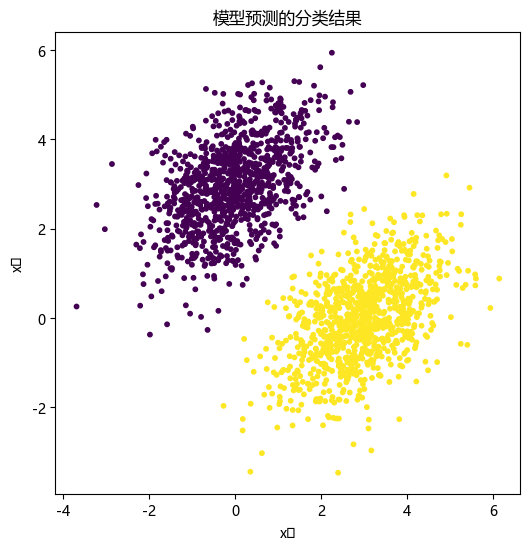

In [18]:
plt.figure(figsize=(6, 6))
plt.scatter(
    inputs[:, 0],
    inputs[:, 1],
    c=predicted_classes[:, 0],   # 用预测类别上色（不是真实标签）
    s=10
)
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.title("模型预测的分类结果")
plt.show()

---
## Cell 16：画出分界线

### 分界线是怎么来的？

模型公式：$\hat{y} = w_1 x_1 + w_2 x_2 + b$

分类阈值是 0.5，所以分界线就是 $\hat{y} = 0.5$ 的那条线：

$$w_1 x_1 + w_2 x_2 + b = 0.5$$

解出 $x_2$：

$$x_2 = \frac{0.5 - b - w_1 x_1}{w_2}$$

这是一条直线。给定一系列 $x_1$ 的值，就能算出对应的 $x_2$，然后画出来。

### 这条线的含义
- 线上方（或左上）的点 → 模型预测为类别0
- 线下方（或右下）的点 → 模型预测为类别1
- （具体哪边是哪类取决于 w₁、w₂ 的正负号）

**线性分类器学到的本质，就是一条能把两类点尽量分开的直线。**

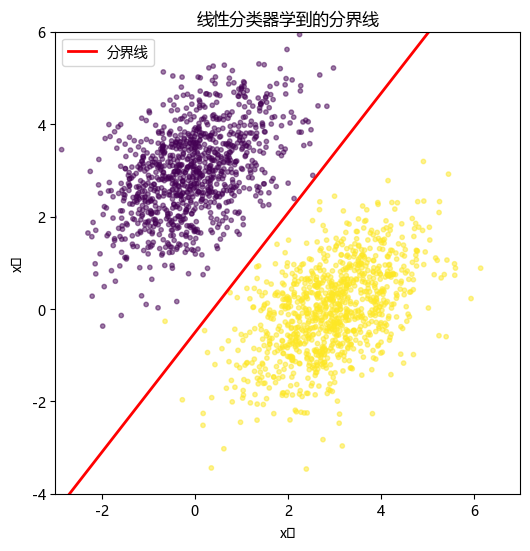


分界线方程：0.1699·x₁ + -0.1313·x₂ + (0.4327) = 0.5
线上方是一类，线下方是另一类。

这就是整个线性分类器的本质：学一条直线把两类点分开。


In [19]:
w = W.numpy()           # w 形状 (2, 1)
b_value = b.numpy()[0]  # b 是一个数

# 在 x₁ 范围内取200个点
x1_range = np.linspace(-3, 7, 200)

# 分界线公式：x₂ = (0.5 - b - w₁×x₁) / w₂
x2_boundary = (0.5 - b_value - w[0, 0] * x1_range) / w[1, 0]

plt.figure(figsize=(6, 6))
# 画原始数据点（用真实标签上色）
plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0], s=10, alpha=0.5)
# 画分界线
plt.plot(x1_range, x2_boundary, color="red", linewidth=2, label="分界线")
plt.xlim(-3, 7)
plt.ylim(-4, 6)
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.title("线性分类器学到的分界线")
plt.legend()
plt.show()

print(f"\n分界线方程：{w[0,0]:.4f}·x₁ + {w[1,0]:.4f}·x₂ + ({b_value:.4f}) = 0.5")
print(f"线上方是一类，线下方是另一类。")
print(f"\n这就是整个线性分类器的本质：学一条直线把两类点分开。")

---
## 总结：对比 MNIST 和这个例子

| | 这个例子 | MNIST |
|---|---|---|
| 输入 | 2个坐标 (x₁, x₂) | 784个像素 |
| 输出 | 1个实数 | 10个概率 |
| 参数数量 | 3个（w₁, w₂, b） | 407,050个 |
| 层数 | 1层（线性） | 2层（线性+ReLU+线性+Softmax） |
| 损失函数 | MSE（均方误差） | 交叉熵（-log） |
| 激活函数 | 无 | ReLU + Softmax |
| 学习率 | 0.1 | 0.001 |
| 训练次数 | 50次 | 4,690次 |
| 本质 | 学一条直线 | 学一个弯曲的决策边界 |

**核心逻辑完全一样**：前向传播 → 算loss → GradientTape反向求梯度 → 减去学习率×梯度。
区别只是参数多少和公式复杂度。